In [ ]:
#Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from pathlib import Path
sns.set_theme(style="whitegrid")

In [ ]:
# Define file paths

base_dir = Path.cwd()

diet_dir = base_dir / "dietstudy_analyses-master" / "data" / "diet"
maps_dir = base_dir / "dietstudy_analyses-master" / "data" / "maps"

nutrition_path = diet_dir / "nutrition_totals.txt"
metadata_path = maps_dir / "food_map.txt"

print("Nutrition path exists:", nutrition_path.exists())
print("Nutrition path:", nutrition_path)

print("Metadata path exists:", metadata_path.exists())
print("Metadata path:", metadata_path)

# print("\nFiles in maps directory:")
# for file in maps_dir.iterdir():
#     print(file.name)

Nutrition path exists: True
Nutrition path: c:\Users\linoy\Documents\proj3\Gut-Microbiome-Project_year3\dietstudy_analyses-master\data\diet\nutrition_totals.txt
Metadata path exists: True
Metadata path: c:\Users\linoy\Documents\proj3\Gut-Microbiome-Project_year3\dietstudy_analyses-master\data\maps\food_map.txt


In [3]:
# Load the nutrition totals data

df_nutrients = pd.read_csv(nutrition_path, sep="\t")

df_nutrients.columns = df_nutrients.columns.str.strip()

print("Nutrients shape:", df_nutrients.shape)

display(df_nutrients.head())

print("Nutrient columns:")
print(df_nutrients.columns.tolist())

Nutrients shape: (580, 107)


,X.SampleID,UserName,StudyDayNo,RecordDayNo,KCAL,PROT,TFAT,CARB,MOIS,ALC,...,PF_LEGUMES,D_TOTAL,D_MILK,D_YOGURT,D_CHEESE,OILS,SOLID_FATS,ADD_SUGARS,A_DRINKS,Replicate
0,MCT.f.0001,MCTs01,Day.01,1,1707.040193,95.668747,55.185318,187.965353,3848.605502,14.95872,...,0.0,3.265577,2.05776,0.646,0.561817,14.668870,21.795872,4.822350,1.072512,1
1,MCT.f.0002,MCTs01,Day.02,2,1970.043625,109.619765,53.615264,242.919015,3808.005721,14.04000,...,0.0,4.156035,2.35656,0.646,1.153475,15.886225,19.139825,4.325970,1.008000,1
2,MCT.f.0003,MCTs01,Day.03,3,1714.895330,89.992993,50.561373,234.225138,4183.622433,0.00000,...,0.0,2.979655,1.12608,0.646,1.207575,11.836920,17.711575,4.758330,0.000000,1
3,MCT.f.0004,MCTs01,Day.04,4,2487.232625,94.611953,92.021551,257.539030,4816.211548,42.44800,...,0.0,3.634460,2.15186,0.000,1.482600,55.308100,19.937800,5.917100,3.035200,1
4,MCT.f.0005,MCTs01,Day.05,5,2260.211176,110.268353,95.570253,165.608070,4404.243876,43.93060,...,0.0,3.379710,2.32071,0.000,1.059000,24.231213,54.613613,5.793898,3.116360,1


Nutrient columns:
['X.SampleID', 'UserName', 'StudyDayNo', 'RecordDayNo', 'KCAL', 'PROT', 'TFAT', 'CARB', 'MOIS', 'ALC', 'CAFF', 'THEO', 'SUGR', 'FIBE', 'CALC', 'IRON', 'MAGN', 'PHOS', 'POTA', 'SODI', 'ZINC', 'COPP', 'SELE', 'VC', 'VB1', 'VB2', 'NIAC', 'VB6', 'FOLA', 'FA', 'FF', 'FDFE', 'VB12', 'VARA', 'RET', 'BCAR', 'ACAR', 'CRYP', 'LYCO', 'LZ', 'ATOC', 'VK', 'CHOLE', 'SFAT', 'S040', 'S060', 'S080', 'S100', 'S120', 'S140', 'S160', 'S180', 'MFAT', 'M161', 'M181', 'M201', 'M221', 'PFAT', 'P182', 'P183', 'P184', 'P204', 'P205', 'P225', 'P226', 'VITD', 'CHOLN', 'VITE_ADD', 'B12_ADD', 'F_TOTAL', 'F_CITMLB', 'F_OTHER', 'F_JUICE', 'V_TOTAL', 'V_DRKGR', 'V_REDOR_TOTAL', 'V_REDOR_TOMATO', 'V_REDOR_OTHER', 'V_STARCHY_TOTAL', 'V_STARCHY_POTATO', 'V_STARCHY_OTHER', 'V_OTHER', 'V_LEGUMES', 'G_TOTAL', 'G_WHOLE', 'G_REFINED', 'PF_TOTAL', 'PF_MPS_TOTAL', 'PF_MEAT', 'PF_CUREDMEAT', 'PF_ORGAN', 'PF_POULT', 'PF_SEAFD_HI', 'PF_SEAFD_LOW', 'PF_EGGS', 'PF_SOY', 'PF_NUTSDS', 'PF_LEGUMES', 'D_TOTAL', 'D_MILK

In [4]:
# Define expected nutrient columns and check which ones are present

nutrient_columns = ["KCAL", "FIBE", "CARB"]

# Try to add fat column automatically if it exists under a common name
fat_candidates = ["FAT", "TFAT", "TotalFat", "Fat", "Total_Fat"]

for col in fat_candidates:
    if col in df_nutrients.columns:
        nutrient_columns.append(col)
        break

existing_nutrient_columns = [col for col in nutrient_columns if col in df_nutrients.columns]

print("Selected nutrient columns:")
print(existing_nutrient_columns)

print("\nMissing expected columns:")
print(set(nutrient_columns) - set(existing_nutrient_columns))

Selected nutrient columns:
['KCAL', 'FIBE', 'CARB', 'TFAT']

Missing expected columns:
set()


In [5]:
# Analyze missing data in the selected nutrient columns

missing_percentages = (
    df_nutrients[existing_nutrient_columns]
    .isnull()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing_df = missing_percentages.reset_index()
missing_df.columns = ["Feature", "Missing Percentage"]

display(missing_df)

,Feature,Missing Percentage
0,KCAL,0.0
1,FIBE,0.0
2,CARB,0.0
3,TFAT,0.0


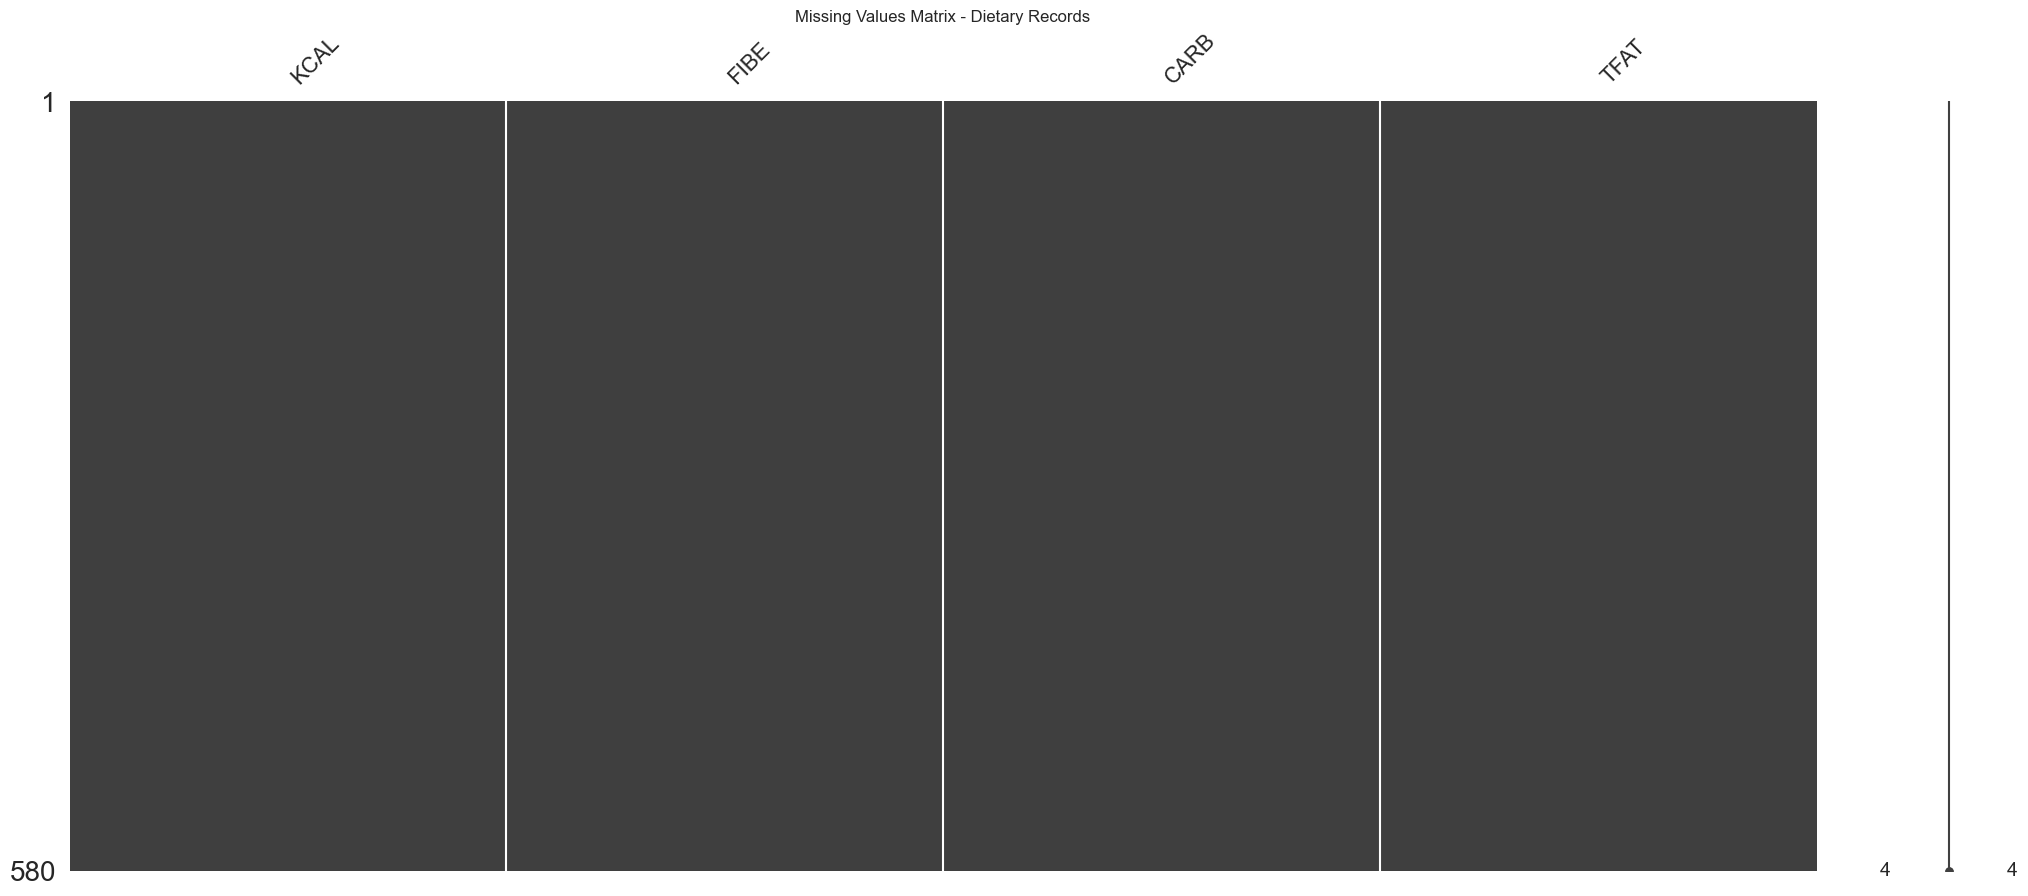

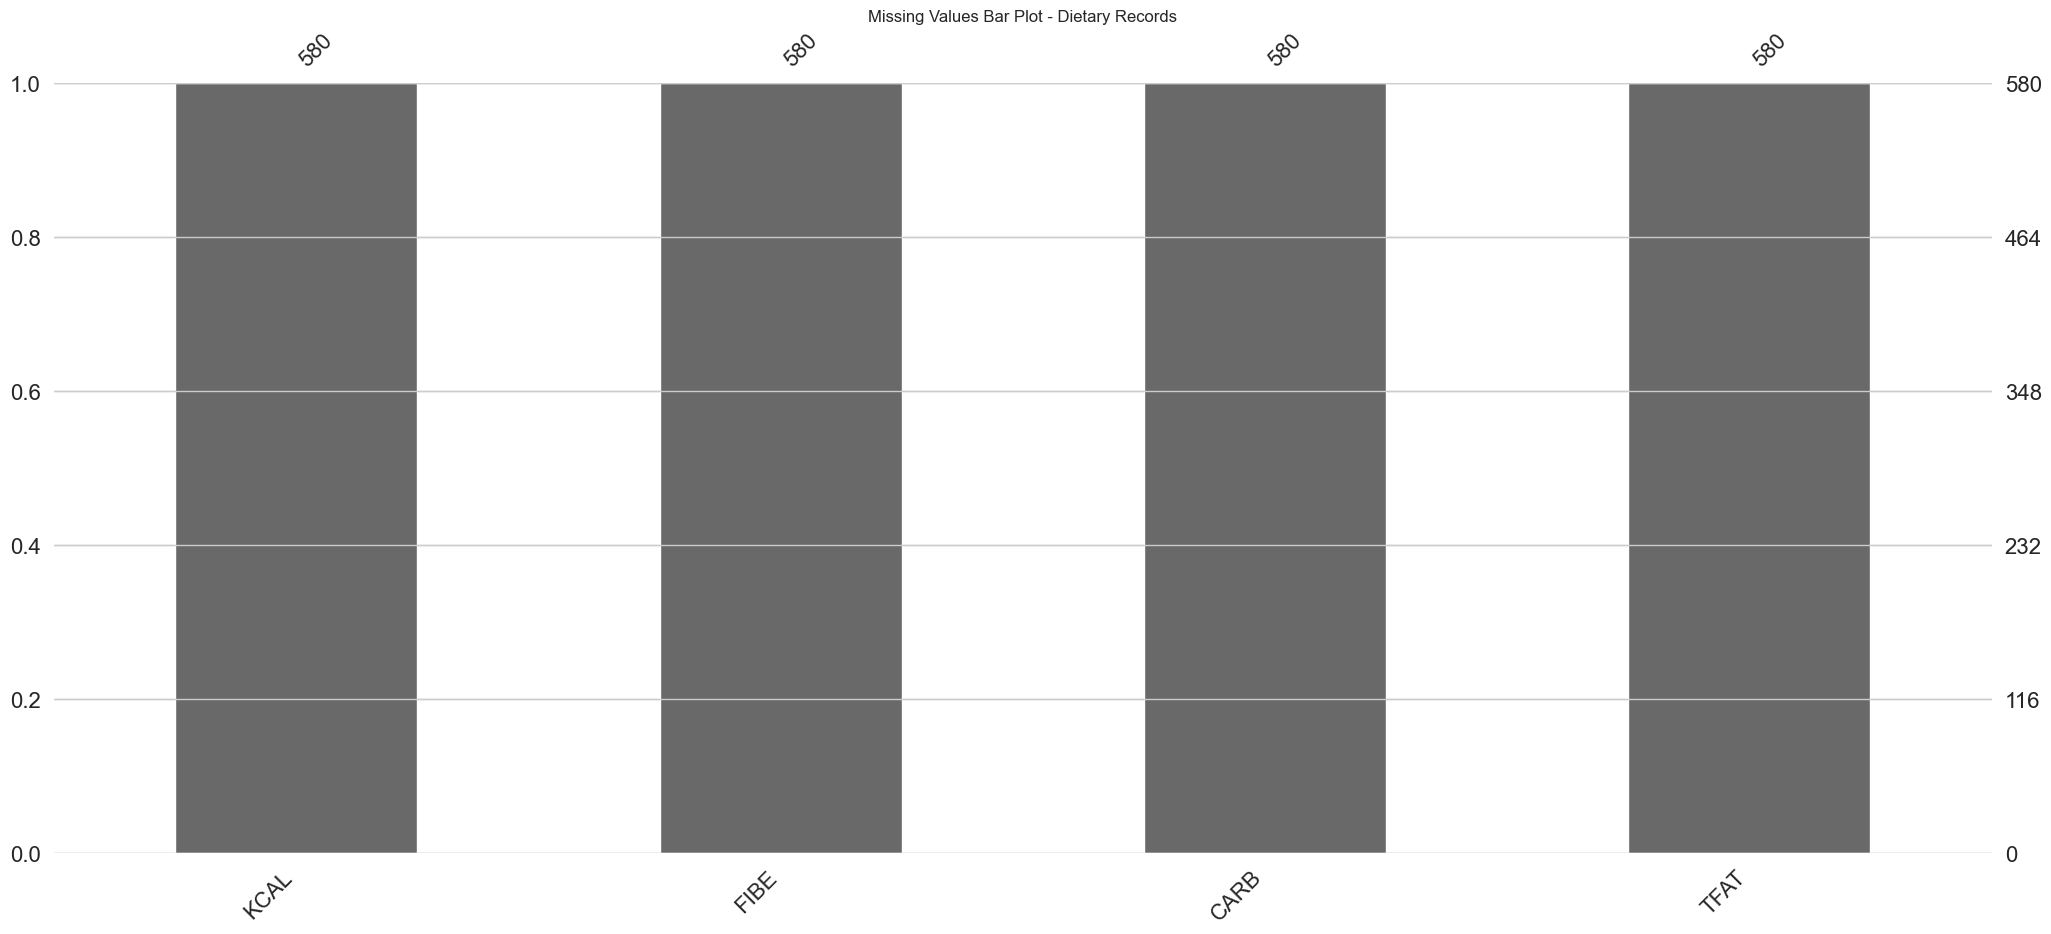

In [6]:
# Visualize missing data patterns

msno.matrix(df_nutrients[existing_nutrient_columns])
plt.title("Missing Values Matrix - Dietary Records")
plt.show()

msno.bar(df_nutrients[existing_nutrient_columns])
plt.title("Missing Values Bar Plot - Dietary Records")
plt.show()

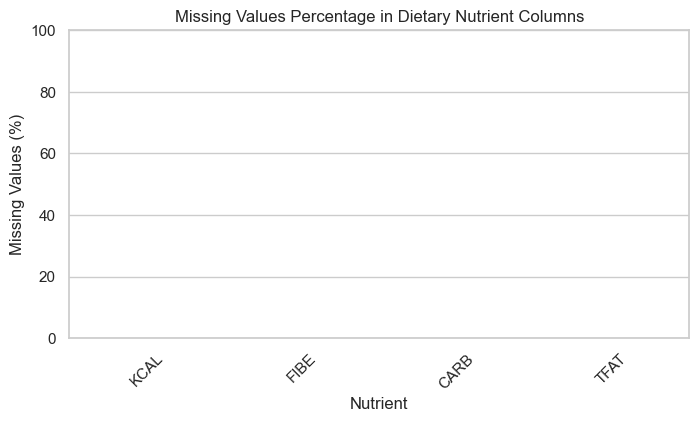

In [7]:
# Create a bar plot for missing percentages

plt.figure(figsize=(8, 4))
sns.barplot(data=missing_df, x="Feature", y="Missing Percentage")
plt.title("Missing Values Percentage in Dietary Nutrient Columns")
plt.xlabel("Nutrient")
plt.ylabel("Missing Values (%)")
plt.ylim(0, 100)
plt.xticks(rotation=45)
plt.show()

In [8]:
# Load participant metadata containing Age and BMI

df_metadata = pd.read_csv(metadata_path, sep="\t")
df_metadata.columns = df_metadata.columns.str.strip()

print("Metadata shape:", df_metadata.shape)
display(df_metadata.head())

print("Metadata columns:")
print(df_metadata.columns.tolist())

Metadata shape: (566, 29)


,#SampleID,UserName,StudyDayNo,StudyDate,Sample.Week.Day,DietDayNo,Diet.Record.Date,Diet.Week.Day,Gender,Age,...,BMI.1,Weight.Change,Run1.Plate,Run2.Rerun,SampleOrder,SampleType,Timing,Activity.Factor,Medications,Dietary.Supp
0,MCT.f.0001,MCTs01,1,1/31/17,Tuesday,0,1/30/17,Monday,F,25.9,...,25.0,-0.4,5.0,NaN,54.0,Sample,Pre,1.375,Nexplanon (bc implant),Multivitamin;VitD;VitC;Zinc
1,MCT.f.0002,MCTs01,2,2/1/17,Wednesday,1,1/31/17,Tuesday,F,25.9,...,25.0,-0.4,1.0,NaN,39.0,Sample,Pre,1.375,Nexplanon (bc implant),Multivitamin;VitD;VitC;Zinc
2,MCT.f.0003,MCTs01,3,2/2/17,Thursday,2,2/1/17,Wednesday,F,25.9,...,25.0,-0.4,1.0,NaN,59.0,Sample,Pre,1.375,Nexplanon (bc implant),Multivitamin;VitD;VitC;Zinc
3,MCT.f.0004,MCTs01,4,2/3/17,Friday,3,2/2/17,Thursday,F,25.9,...,25.0,-0.4,5.0,NaN,32.0,Sample,Pre,1.375,Nexplanon (bc implant),Multivitamin;VitD;VitC;Zinc
4,MCT.f.0005,MCTs01,5,2/4/17,Saturday,4,2/3/17,Friday,F,25.9,...,25.0,-0.4,2.0,Yes,89.0,Sample,Pre,1.375,Nexplanon (bc implant),Multivitamin;VitD;VitC;Zinc


Metadata columns:
['#SampleID', 'UserName', 'StudyDayNo', 'StudyDate', 'Sample.Week.Day', 'DietDayNo', 'Diet.Record.Date', 'Diet.Week.Day', 'Gender', 'Age', 'Weight', 'Height', 'BMI', 'Supplement', 'Waist.Circumference', 'Study.Status', 'oilGrams.assigned', 'fecal.status', 'fecal.time', 'BMI.1', 'Weight.Change', 'Run1.Plate', 'Run2.Rerun', 'SampleOrder', 'SampleType', 'Timing', 'Activity.Factor', 'Medications', 'Dietary.Supp']


In [9]:
# Select participant-level metadata columns

profile_columns = ["Age", "BMI"]

df_profile = (
    df_metadata[["UserName"] + profile_columns]
    .drop_duplicates(subset="UserName")
    .copy()
)

print("Profile dataframe shape:", df_profile.shape)
display(df_profile.head())

print("Missing values in profile columns:")
display(df_profile[profile_columns].isnull().mean().mul(100))

Profile dataframe shape: (34, 3)


,UserName,Age,BMI
0,MCTs01,25.9,25.0
17,MCTs03,25.4,26.6
33,MCTs04,24.0,18.9
50,MCTs05,23.1,19.9
57,MCTs06,23.7,22.7


Missing values in profile columns:


Age    0.0
BMI    0.0
dtype: float64

In [10]:
# Aggregate daily dietary records into average nutrient intake per participant

df_dietary_analysis = (
    df_nutrients
    .groupby("UserName")[existing_nutrient_columns]
    .mean()
    .reset_index()
)

print("Dietary analysis shape:", df_dietary_analysis.shape)
display(df_dietary_analysis.head())

Dietary analysis shape: (37, 5)


,UserName,KCAL,FIBE,CARB,TFAT
0,MCTs01,2233.971687,23.530833,246.315305,72.793184
1,MCTs02,1406.094472,12.205770,102.572981,88.889560
2,MCTs03,3797.839598,32.528277,379.484855,179.378471
3,MCTs04,2554.895951,33.822869,259.635868,123.521241
4,MCTs05,1459.168123,13.046344,193.945721,51.869562


In [11]:
# Merge dietary averages with participant metadata

df_analysis_full = df_dietary_analysis.merge(
    df_profile,
    on="UserName",
    how="left"
)

print("Full analysis dataframe shape:", df_analysis_full.shape)
display(df_analysis_full.head())

print("Missing values after merge:")
display(df_analysis_full[existing_nutrient_columns + profile_columns].isnull().mean().mul(100))

Full analysis dataframe shape: (37, 7)


,UserName,KCAL,FIBE,CARB,TFAT,Age,BMI
0,MCTs01,2233.971687,23.530833,246.315305,72.793184,25.9,25.0
1,MCTs02,1406.094472,12.205770,102.572981,88.889560,NaN,NaN
2,MCTs03,3797.839598,32.528277,379.484855,179.378471,25.4,26.6
3,MCTs04,2554.895951,33.822869,259.635868,123.521241,24.0,18.9
4,MCTs05,1459.168123,13.046344,193.945721,51.869562,23.1,19.9


Missing values after merge:


KCAL    0.000000
FIBE    0.000000
CARB    0.000000
TFAT    0.000000
Age     8.108108
BMI     8.108108
dtype: float64

In [12]:
# Missing values summary after merging dietary records with participant metadata

missing_after_merge = (
    df_analysis_full[existing_nutrient_columns + profile_columns]
    .isnull()
    .sum()
    .reset_index()
)

missing_after_merge.columns = ["Feature", "Missing Count"]
missing_after_merge["Missing Percentage"] = (
    missing_after_merge["Missing Count"] / len(df_analysis_full) * 100
)

display(missing_after_merge)

,Feature,Missing Count,Missing Percentage
0,KCAL,0,0.000000
1,FIBE,0,0.000000
2,CARB,0,0.000000
3,TFAT,0,0.000000
4,Age,3,8.108108
5,BMI,3,8.108108


In [13]:
# Identify participants with dietary records but missing participant metadata

missing_profile_users = df_analysis_full[
    df_analysis_full["Age"].isna() | df_analysis_full["BMI"].isna()
]["UserName"].tolist()

print("Number of participants with missing Age/BMI:", len(missing_profile_users))
print("Participants with missing Age/BMI:")
print(missing_profile_users)

Number of participants with missing Age/BMI: 3
Participants with missing Age/BMI:
['MCTs02', 'MCTs17', 'MCTs30']


In [14]:
# Compare participants available in dietary records vs. participant metadata

diet_users = set(df_dietary_analysis["UserName"])
profile_users = set(df_profile["UserName"])

users_only_in_diet = sorted(diet_users - profile_users)
users_only_in_profile = sorted(profile_users - diet_users)

print("Number of participants in dietary records:", len(diet_users))
print("Number of participants in metadata:", len(profile_users))

print("\nParticipants found in dietary records but missing from metadata:")
print(users_only_in_diet)

print("\nParticipants found in metadata but missing from dietary records:")
print(users_only_in_profile)

Number of participants in dietary records: 37
Number of participants in metadata: 34

Participants found in dietary records but missing from metadata:
['MCTs02', 'MCTs17', 'MCTs30']

Participants found in metadata but missing from dietary records:
[]


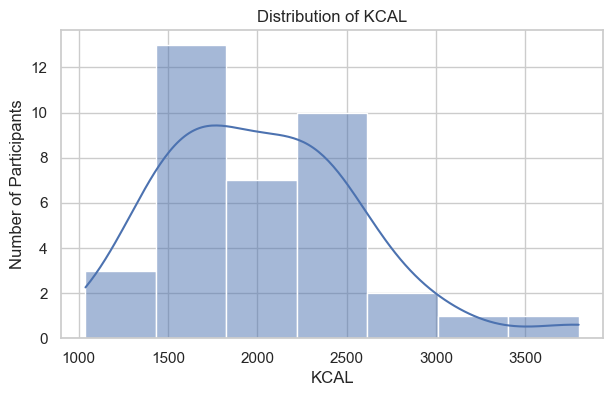

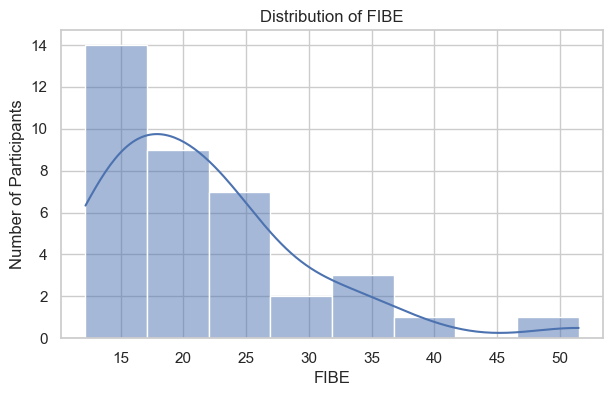

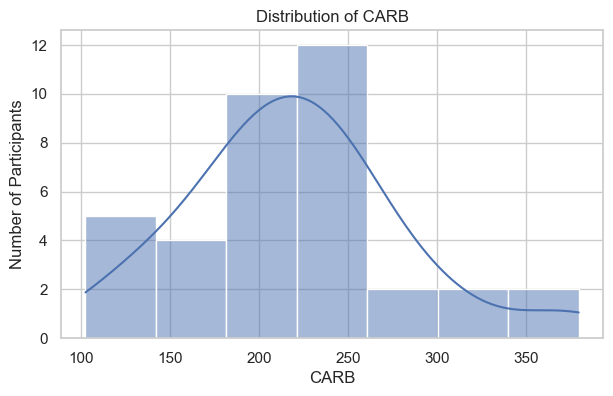

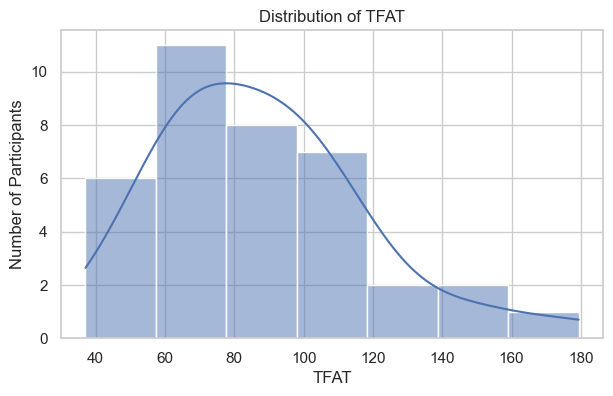

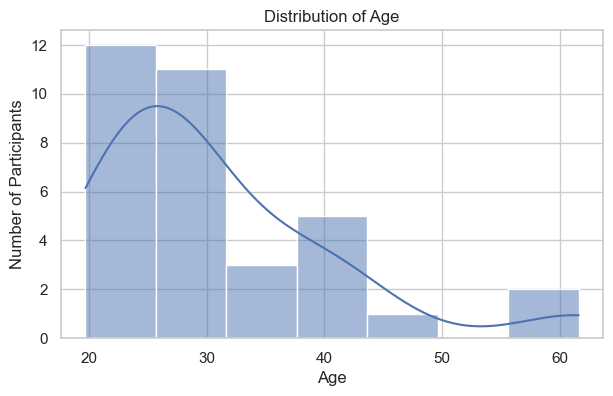

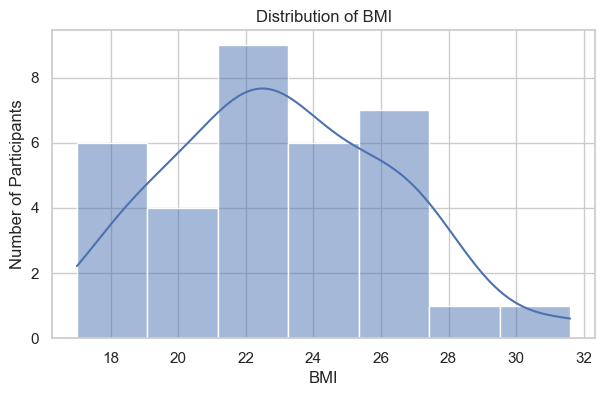

In [15]:
# Histograms for nutrient intake and participant characteristics

analysis_columns = existing_nutrient_columns + profile_columns

for col in analysis_columns:
    plt.figure(figsize=(7, 4))
    sns.histplot(df_analysis_full[col].dropna(), kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Number of Participants")
    plt.show()

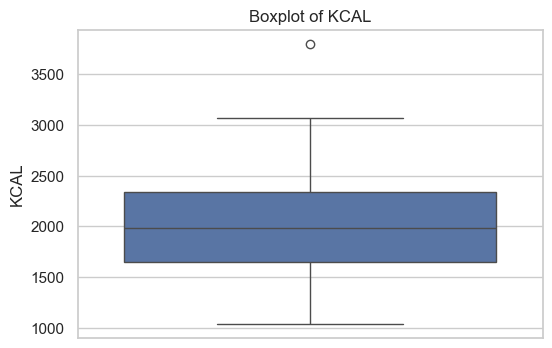

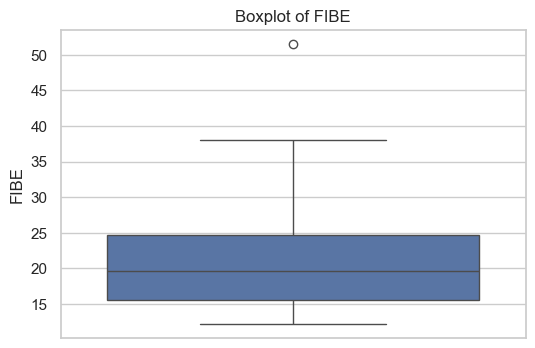

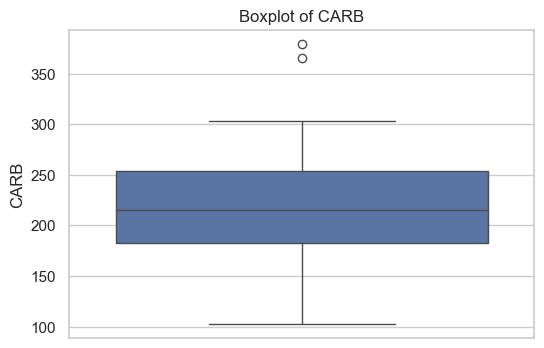

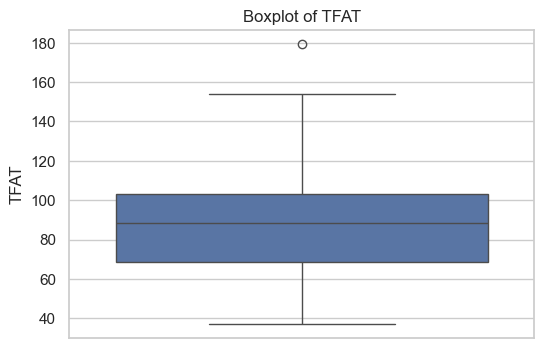

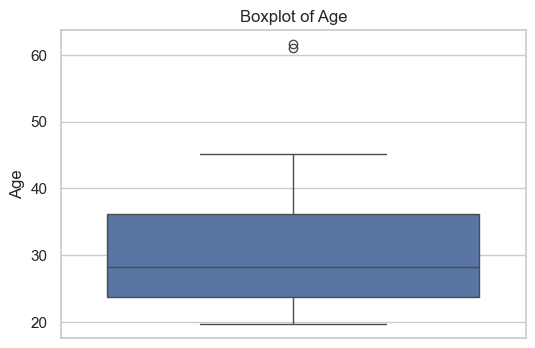

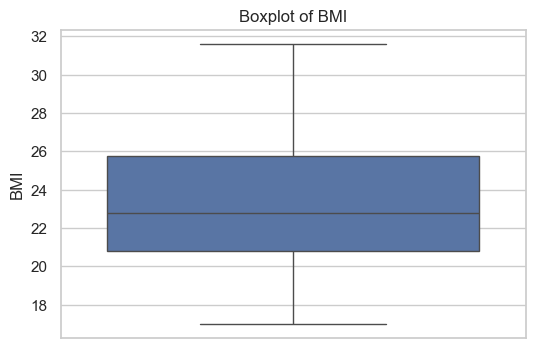

In [16]:
# Boxplots for nutrient intake and participant characteristics

for col in analysis_columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=df_analysis_full[col].dropna())
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.show()

In [17]:
# Create a complete-case dataset for analyses requiring participant metadata

df_analysis_complete = df_analysis_full.dropna(subset=["Age", "BMI"]).copy()

print("Original merged dataset shape:", df_analysis_full.shape)
print("Complete-case dataset shape:", df_analysis_complete.shape)

display(df_analysis_complete.head())

Original merged dataset shape: (37, 7)
Complete-case dataset shape: (34, 7)


,UserName,KCAL,FIBE,CARB,TFAT,Age,BMI
0,MCTs01,2233.971687,23.530833,246.315305,72.793184,25.9,25.0
2,MCTs03,3797.839598,32.528277,379.484855,179.378471,25.4,26.6
3,MCTs04,2554.895951,33.822869,259.635868,123.521241,24.0,18.9
4,MCTs05,1459.168123,13.046344,193.945721,51.869562,23.1,19.9
5,MCTs06,2821.157393,25.010255,300.566053,119.229383,23.7,22.7


In [ ]:
# Descriptive statistics for dietary and participant-level variables

summary_stats = df_analysis_full[analysis_columns].describe().T
display(summary_stats)

,count,mean,std,min,25%,50%,75%,max
KCAL,37.0,2033.297533,555.341419,1038.411469,1647.969946,1986.314418,2338.837036,3797.839598
FIBE,37.0,21.501996,8.227874,12.205770,15.555740,19.614496,24.741995,51.493771
CARB,37.0,219.889581,60.207579,102.572981,183.135589,215.304862,253.876709,379.484855
TFAT,37.0,88.114532,30.307293,37.064239,68.770390,88.392512,103.046069,179.378471
Age,34.0,30.823529,10.263264,19.700000,23.750000,28.200000,36.125000,61.600000
BMI,34.0,23.091176,3.315470,17.000000,20.800000,22.800000,25.750000,31.600000


In [ ]:
# Descriptive statistics for dietary and participant-level variables without missing metadata


summary_stats = df_analysis_complete[analysis_columns].describe().T
display(summary_stats)

,count,mean,std,min,25%,50%,75%,max
KCAL,34.0,2080.282967,554.371204,1038.411469,1720.475921,2053.170958,2381.937003,3797.839598
FIBE,34.0,21.914465,8.363119,12.578621,16.016949,20.144428,24.943190,51.493771
CARB,34.0,226.308557,57.376045,118.539338,194.193916,224.196062,255.340657,379.484855
TFAT,34.0,89.682832,30.884412,37.064239,69.391504,89.026639,105.218414,179.378471
Age,34.0,30.823529,10.263264,19.700000,23.750000,28.200000,36.125000,61.600000
BMI,34.0,23.091176,3.315470,17.000000,20.800000,22.800000,25.750000,31.600000


## Summary

This notebook profiles the dietary records and participant metadata.

The analysis includes:
- Loading daily dietary records from `nutrition_totals.txt`.
- Selecting key dietary variables: calories (`KCAL`), fiber (`FIBE`), carbohydrates (`CARB`), and total fat (`TFAT`).
- Calculating missing-value percentages for dietary variables.
- Visualizing missing values using `missingno`.
- Aggregating dietary records into average intake per participant.
- Loading participant metadata from `food_map.txt`.
- Adding participant-level characteristics: `Age` and `BMI`.
- Plotting histograms and boxplots for nutrient intake and participant characteristics.

These variables can later be used as control variables / confounders in downstream microbiome analysis.